In [ ]:
import time
import math
import urllib.request
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "tinyshakespeare.txt"

try:
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    with open(DATA_PATH, "r", encoding="utf-8") as f:
        text = f.read()
except Exception as e:
    raise RuntimeError(
        "Could not download Tiny Shakespeare automatically. "
        "If your course provided its own data-loader/file, load it here instead, "
        f"e.g.: with open('/content/tinyshakespeare.txt') as f: text = f.read()\nOriginal error: {e}"
    )

print("Total characters:", len(text))
print(text[:300])


Total characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [ ]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ints):
    return "".join(itos[i] for i in ints)

data = torch.tensor(encode(text), dtype=torch.long)
print("Vocab size:", vocab_size)
print("Encoded length:", len(data))


Vocab size: 65
Encoded length: 1115394


In [ ]:
class CharWindowDataset(Dataset):
    def __init__(self, data, seq_len):
        self.seq_len = seq_len
        self.data = data
        self.num_samples = len(data) - seq_len

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x = self.data[idx: idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return x, y


MAX_TRAIN_SAMPLES = 50000
MAX_VAL_SAMPLES = 5000

def make_loaders(data, seq_len, val_frac=0.1, batch_size=128):
    full_ds = CharWindowDataset(data, seq_len)
    n_val = max(1, int(len(full_ds) * val_frac))
    n_train = len(full_ds) - n_val
    train_ds, val_ds = torch.utils.data.random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    if MAX_TRAIN_SAMPLES is not None and len(train_ds) > MAX_TRAIN_SAMPLES:
        idx = torch.randperm(len(train_ds))[:MAX_TRAIN_SAMPLES]
        train_ds = torch.utils.data.Subset(train_ds, idx.tolist())
    if MAX_VAL_SAMPLES is not None and len(val_ds) > MAX_VAL_SAMPLES:
        idx = torch.randperm(len(val_ds))[:MAX_VAL_SAMPLES]
        val_ds = torch.utils.data.Subset(val_ds, idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=64, n_heads=2, n_layers=2,
                 d_ff=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="relu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        h = self.token_emb(x) + self.pos_emb(positions)
        h = self.dropout(h)
        h = self.encoder(h, mask=self.causal_mask[:T, :T])
        last_hidden = h[:, -1, :]
        logits = self.fc_out(last_hidden)
        return logits

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def estimate_transformer_flops(seq_len, d_model, n_heads, n_layers, d_ff):
    attn_proj_flops = 4 * seq_len * d_model * d_model
    attn_score_flops = 2 * seq_len * seq_len * d_model
    ffn_flops = 2 * seq_len * d_model * d_ff * 2
    per_layer = attn_proj_flops + attn_score_flops + ffn_flops
    return per_layer * n_layers


In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=3e-3, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses, val_accuracies = [], [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_train_loss = total_loss / n_batches
        train_losses.append(avg_train_loss)

        model.eval()
        correct, total, val_loss_sum, val_batches = 0, 0, 0.0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss_sum += loss.item()
                val_batches += 1
                preds = logits.argmax(dim=-1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        avg_val_loss = val_loss_sum / val_batches
        val_acc = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
            print(f"  Epoch {epoch+1:3d}/{epochs} | train_loss={avg_train_loss:.4f} "
                  f"| val_loss={avg_val_loss:.4f} | val_acc={val_acc:.4f}")

    training_time = time.time() - start_time


    model.eval()
    infer_start = time.time()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            _ = model(x)
    inference_time = time.time() - infer_start

    perplexity = math.exp(val_losses[-1])
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_acc": val_accuracies[-1],
        "best_val_acc": max(val_accuracies),
        "perplexity": perplexity,
        "training_time_sec": training_time,
        "inference_time_sec": inference_time,
    }


In [ ]:
D_MODEL, D_FF, EPOCHS = 64, 128, 15
baseline_results = {}

for seq_len in [20, 30]:
    print(f"\nBaseline Transformer (2 blocks, 2 heads) | seq_len={seq_len} ")
    train_loader, val_loader = make_loaders(data, seq_len)
    model = CharTransformer(vocab_size, seq_len, d_model=D_MODEL, n_heads=2,
                             n_layers=2, d_ff=D_FF)
    n_params = model.count_params()
    flops = estimate_transformer_flops(seq_len, D_MODEL, 2, 2, D_FF)

    metrics = train_model(model, train_loader, val_loader, epochs=EPOCHS)
    metrics["num_params"] = n_params
    metrics["approx_flops_per_forward"] = flops
    baseline_results[seq_len] = metrics

    print(f"  -> final_val_acc={metrics['final_val_acc']:.4f} | perplexity={metrics['perplexity']:.2f} "
          f"| train_time={metrics['training_time_sec']:.1f}s | params={n_params:,}")



Baseline Transformer (2 blocks, 2 heads) | seq_len=20 
  Epoch   1/15 | train_loss=2.5869 | val_loss=2.2689 | val_acc=0.3452
  Epoch   5/15 | train_loss=2.1324 | val_loss=2.0250 | val_acc=0.4102
  Epoch  10/15 | train_loss=2.0312 | val_loss=1.9445 | val_acc=0.4248
  Epoch  15/15 | train_loss=1.9817 | val_loss=1.8978 | val_acc=0.4434
  -> final_val_acc=0.4434 | perplexity=6.67 | train_time=42.9s | params=76,609

Baseline Transformer (2 blocks, 2 heads) | seq_len=30 
  Epoch   1/15 | train_loss=2.5946 | val_loss=2.2839 | val_acc=0.3514
  Epoch   5/15 | train_loss=2.1328 | val_loss=2.0360 | val_acc=0.4066
  Epoch  10/15 | train_loss=2.0260 | val_loss=1.9519 | val_acc=0.4332
  Epoch  15/15 | train_loss=1.9748 | val_loss=1.9235 | val_acc=0.4308
  -> final_val_acc=0.4308 | perplexity=6.84 | train_time=43.9s | params=77,249


In [ ]:
SWEEP_SEQ_LEN = 30
block_options = [1, 2, 4]
head_options = [2, 4]

sweep_results = []
train_loader, val_loader = make_loaders(data, SWEEP_SEQ_LEN)

for n_layers in block_options:
    for n_heads in head_options:
        print(f"\nSweep: n_layers={n_layers}, n_heads={n_heads}, seq_len={SWEEP_SEQ_LEN} ")
        model = CharTransformer(vocab_size, SWEEP_SEQ_LEN, d_model=D_MODEL,
                                 n_heads=n_heads, n_layers=n_layers, d_ff=D_FF)
        n_params = model.count_params()
        flops = estimate_transformer_flops(SWEEP_SEQ_LEN, D_MODEL, n_heads, n_layers, D_FF)

        metrics = train_model(model, train_loader, val_loader, epochs=EPOCHS, verbose=False)

        row = {
            "n_layers": n_layers,
            "n_heads": n_heads,
            "final_val_acc": metrics["final_val_acc"],
            "best_val_acc": metrics["best_val_acc"],
            "perplexity": metrics["perplexity"],
            "training_time_sec": metrics["training_time_sec"],
            "inference_time_sec": metrics["inference_time_sec"],
            "num_params": n_params,
            "approx_flops_per_forward": flops,
        }
        sweep_results.append(row)
        print(f"  -> val_acc={row['final_val_acc']:.4f} | perplexity={row['perplexity']:.2f} "
              f"| train_time={row['training_time_sec']:.1f}s | infer_time={row['inference_time_sec']:.3f}s "
              f"| params={n_params:,}")



Sweep: n_layers=1, n_heads=2, seq_len=30 
  -> val_acc=0.4272 | perplexity=7.14 | train_time=30.3s | infer_time=0.067s | params=43,777

Sweep: n_layers=1, n_heads=4, seq_len=30 
  -> val_acc=0.4378 | perplexity=6.83 | train_time=30.9s | infer_time=0.061s | params=43,777

Sweep: n_layers=2, n_heads=2, seq_len=30 
  -> val_acc=0.4498 | perplexity=6.81 | train_time=42.9s | infer_time=0.080s | params=77,249

Sweep: n_layers=2, n_heads=4, seq_len=30 
  -> val_acc=0.4492 | perplexity=6.55 | train_time=43.9s | infer_time=0.091s | params=77,249

Sweep: n_layers=4, n_heads=2, seq_len=30 
  -> val_acc=0.4542 | perplexity=6.50 | train_time=68.8s | infer_time=0.154s | params=144,193

Sweep: n_layers=4, n_heads=4, seq_len=30 
  -> val_acc=0.4496 | perplexity=6.44 | train_time=69.1s | infer_time=0.110s | params=144,193


In [ ]:
import pandas as pd

sweep_df = pd.DataFrame(sweep_results)
sweep_df = sweep_df.sort_values(["n_layers", "n_heads"]).reset_index(drop=True)
sweep_df


,n_layers,n_heads,final_val_acc,best_val_acc,perplexity,training_time_sec,inference_time_sec,num_params,approx_flops_per_forward
0,1,2,0.4272,0.4276,7.138402,30.261778,0.066550,43777,1589760
1,1,4,0.4378,0.4378,6.826493,30.903330,0.061481,43777,1589760
2,2,2,0.4498,0.4498,6.811880,42.927178,0.080329,77249,3179520
3,2,4,0.4492,0.4492,6.550185,43.889974,0.091181,77249,3179520
4,4,2,0.4542,0.4542,6.504656,68.797361,0.153827,144193,6359040
5,4,4,0.4496,0.4514,6.437828,69.099816,0.109564,144193,6359040


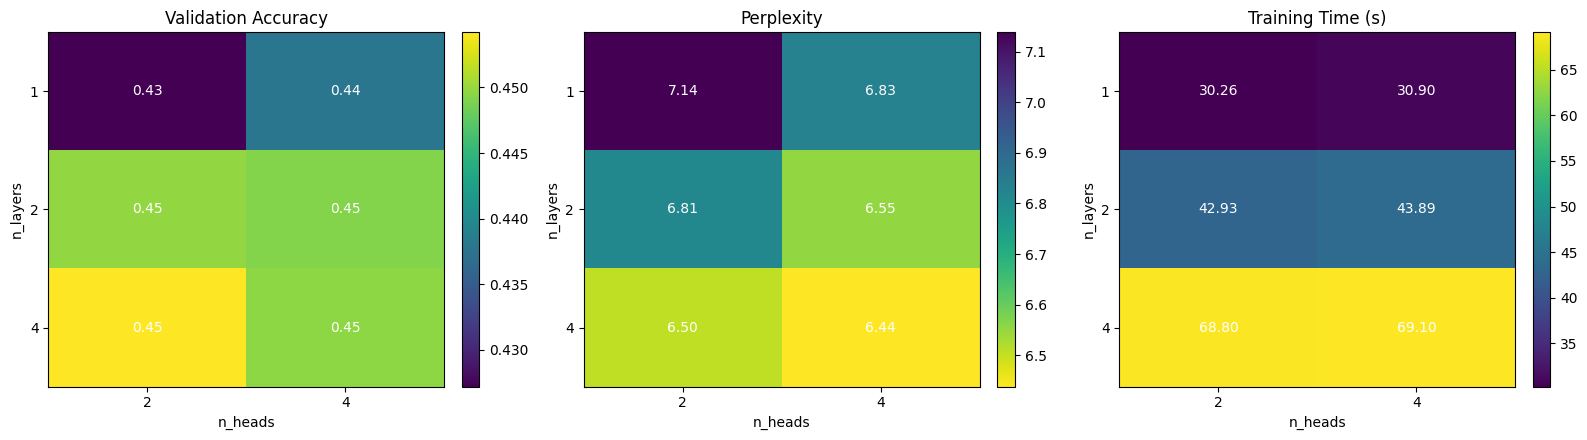

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

acc_pivot = sweep_df.pivot(index="n_layers", columns="n_heads", values="final_val_acc")
ppl_pivot = sweep_df.pivot(index="n_layers", columns="n_heads", values="perplexity")
time_pivot = sweep_df.pivot(index="n_layers", columns="n_heads", values="training_time_sec")

for ax, pivot, title, cmap in [
    (axes[0], acc_pivot, "Validation Accuracy", "viridis"),
    (axes[1], ppl_pivot, "Perplexity", "viridis_r"),
    (axes[2], time_pivot, "Training Time (s)", "viridis"),
]:
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("n_heads")
    ax.set_ylabel("n_layers")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", color="white")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("hyperparam_sweep.png", dpi=150)
plt.show()


In [ ]:
SEQ_LEN_50 = 50
train_loader_50, val_loader_50 = make_loaders(data, SEQ_LEN_50)

model_50 = CharTransformer(vocab_size, SEQ_LEN_50, d_model=D_MODEL, n_heads=2,
                            n_layers=2, d_ff=D_FF)
n_params_50 = model_50.count_params()
flops_50 = estimate_transformer_flops(SEQ_LEN_50, D_MODEL, 2, 2, D_FF)

print(f"Transformer (2 blocks, 2 heads) | seq_len={SEQ_LEN_50}")
metrics_50 = train_model(model_50, train_loader_50, val_loader_50, epochs=EPOCHS)

print(f"\nFinal val_acc={metrics_50['final_val_acc']:.4f} | perplexity={metrics_50['perplexity']:.2f} "
      f"| train_time={metrics_50['training_time_sec']:.1f}s | params={n_params_50:,} "
      f"| approx_flops={flops_50:,}")


Transformer (2 blocks, 2 heads) | seq_len=50
  Epoch   1/15 | train_loss=2.6283 | val_loss=2.3621 | val_acc=0.3218
  Epoch   5/15 | train_loss=2.1584 | val_loss=2.1306 | val_acc=0.3676
  Epoch  10/15 | train_loss=2.0510 | val_loss=2.0394 | val_acc=0.4026
  Epoch  15/15 | train_loss=1.9990 | val_loss=1.9877 | val_acc=0.4100

Final val_acc=0.4100 | perplexity=7.30 | train_time=46.0s | params=78,529 | approx_flops=5,555,200
